In [19]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.special import gammaln
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [2]:
data = np.load("/Users/egeacareti/Statistics-Course/Statistics_meerburg_2026_fork/Lectures/data/higgs_binned.npy")
inv_m = data[:, 0]
n = data[:, 1]
delta_m = data[:, 2]
N = len(inv_m)

In [15]:
def ptform_full(u):
    """
    Transforms the unit hypercube `u` to our parameter bounds.
    Parameters: [mu, sigma, A, B, alpha]
    """
    x = np.array(u)
    x[0] = 110.0 + u[0] * 30.0    # mu: Uniform[110, 140]
    x[1] = 0.5 + u[1] * 4.5       # sigma: Uniform[0.5, 5.0]
    x[2] = 0.1 + u[2] * 10000.0           # A (Signal): Uniform[0, 10000]
    x[3] = 0.1 + u[3] * 50000.0          # B (Background): Uniform[0, 50000]
    x[4] = u[4] * 3             # alpha: Uniform[0, 3]
    return x

def loglike_full(theta):
    mu, sigma, A, B, alpha = theta
    
    # Calculate predicted rates
    signal = A * np.exp(-0.5 * ((inv_m - mu) / sigma)**2)
    bg = B * np.exp(-alpha * inv_m)
    lambda_i = delta_m * (signal + bg)
    
    # Guard against non-positive predictions
    if np.any(lambda_i <= 0):
        return -np.inf
    
    # Poisson Log-Likelihood
    return np.sum(n * np.log(lambda_i) - lambda_i - gammaln(n + 1))

def ptform_null(u):
    """
    Parameters: [B, alpha]
    """
    x = np.array(u)
    x[0] = u[0] * 50000.0          # B (Background): Uniform[0, 50000]
    x[1] = u[1] * 3             # alpha: Uniform[0, 3]
    return x

def loglike_null(theta):
    B, alpha = theta
    
    lambda_i = delta_m * (B * np.exp(-alpha * inv_m))
        
    return np.sum(n * np.log(lambda_i) - lambda_i - gammaln(n + 1))

In [16]:
ndim_full = 5
sampler_full = dynesty.NestedSampler(loglike_full, ptform_full, ndim_full)
sampler_full.run_nested(dlogz=0.5)
res_full = sampler_full.results

ndim_null = 2
sampler_null = dynesty.NestedSampler(loglike_null, ptform_null, ndim_null)
sampler_null.run_nested(print_progress=False)
res_null = sampler_null.results

iter: 2310 | bound: 11 | nc: 135 | ncall: 23174 | eff(%):  9.968 | loglstar:   -inf < -36153.500 <    inf | logz: -36165.023 +/-  0.152 | dlogz: 35878.175 >  0.500                                   /Users/egeacareti/Statistics-Course/Statistics_meerburg_2026_fork/Working/myenv/lib/python3.14/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 2321 | bound: 12 | nc: 30 | ncall: 24000 | eff(%):  9.671 | loglstar:   -inf < -35814.696 <    inf | logz: -35826.241 +/-  0.152 | dlogz: 35566.737 >  0.500                                    /Users/egeacareti/Statistics-Course/Statistics_meerburg_2026_fork/Workin

In [17]:
# Extract the final log-evidence from both runs
logZ_full = res_full.logz[-1]
Z_full = np.exp(logZ_full)

logZ_null = res_null.logz[-1]
Z_null = np.exp(logZ_null)

# Calculate Log Bayes Factor (ln B)
B_fn = Z_full / Z_null

print("--- BAYESIAN EVIDENCE REPORT ---")
print(f"Full Model evidence: {Z_full}")
print(f"Null Model evidence: {Z_null}")
print(f"Bayes Factor: {B_fn}")

--- BAYESIAN EVIDENCE REPORT ---
Full Model evidence: 1.0582150547927457e-104
Null Model evidence: 5.466579522288056e-131
Bayes Factor: 1.9357901050890156e+26


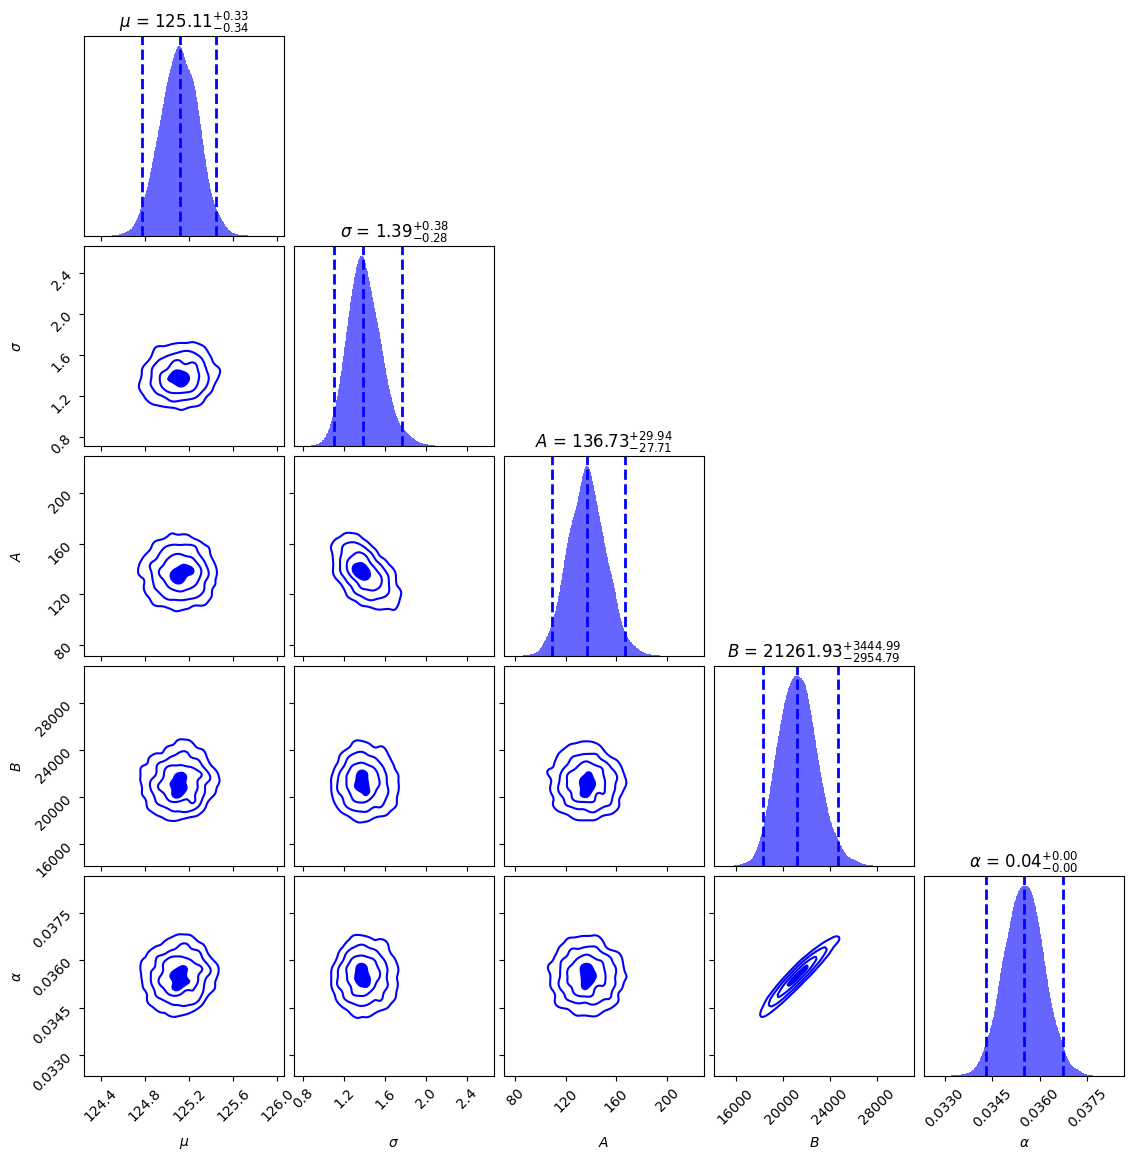

In [20]:
# Labels for the corner plot
labels = [r"$\mu$", r"$\sigma$", r"$A$", r"$B$", r"$\alpha$"]

# Plotting the Corner Plot using dynesty's built-in tool
fig, axes = dyplot.cornerplot(res_full, labels=labels, color='blue', 
                              show_titles=True, title_kwargs={'fontsize': 12})
plt.show()